In [ ]:
import os
import pandas as pd
from google.colab import drive

# 1. Montage du Drive
drive.mount('/content/drive')

# 2. Définition du chemin
base_path = "/content/drive/MyDrive/WOS11967/"

# 3. Chargement direct des données
with open(os.path.join(base_path, "X.txt"), "r", encoding="utf-8") as f:
    X_data = f.read().splitlines()

with open(os.path.join(base_path, "YL1.txt"), "r", encoding="utf-8") as f:
    YL1_data = f.read().splitlines()
with open(os.path.join(base_path, "YL2.txt"), "r", encoding="utf-8") as f:
      YL2_data = f.read().splitlines()
with open(os.path.join(base_path, "Y.txt"), "r", encoding="utf-8") as f:
      Y_data = f.read().splitlines()

# 4. Création du DataFrame (Le prof veut prédire le premier seulement : YL1)
df = pd.DataFrame({
    "texte": X_data,
    "YL1": YL1_data,
    "YL2": YL2_data,
     "Y": Y_data
})

print("Chargement réussi !")
print(df)

Mounted at /content/drive
Chargement réussi !
                                                   texte YL1 YL2   Y
0      The aim of this study was to investigate (a) t...   2   2  10
1      The detection of negative emotions through dai...   0   1   1
2      DNA/RNA sequencing has recently become a prima...   6   1  29
3      Primary European car-makers agree on a 48 V em...   3   3  16
4      Background: Chronic alcohol intake impacts ski...   5   0  23
...                                                  ...  ..  ..  ..
11962  Dense motion field estimation is a key compute...   0   0   0
11963  Background: The Generation Scotland: Scottish ...   6   4  32
11964  Purpose The application of organic and inorgan...   4   4  22
11965  The pathophysiological changes associated with...   6   2  30
11966  During the last decades photogrammetric comput...   0   0   0

[11967 rows x 4 columns]


In [ ]:
# Exemple : récupérer un texte représentatif pour chaque classe
classes_YL1 = sorted(df['YL1'].unique())
representatifs = {c: df[df['YL1']==c]['texte'].iloc[0][:50]+"..." for c in classes_YL1}
print(representatifs)


{'0': 'The detection of negative emotions through daily a...', '1': 'Transient analysis of Switching Power Converter (S...', '2': 'The aim of this study was to investigate (a) the b...', '3': 'Primary European car-makers agree on a 48 V embedd...', '4': 'Service reputation is a key factor for service sel...', '5': 'Background: Chronic alcohol intake impacts skin di...', '6': 'DNA/RNA sequencing has recently become a primary w...'}


In [ ]:
# 1. On s'assure que tout est bien au format numérique
df['Y'] = df['Y'].astype(int)
df['YL1'] = df['YL1'].astype(int)
df['YL2'] = df['YL2'].astype(int)

# 2. On extrait les anomalies (celles que tu as vues dans tes résultats)
# Pour Y = 10, la modalité rare était YL2 = 3
anomalie_10 = df[(df['Y'] == 10) & (df['YL2'] == 3)]

# Pour Y = 6, la modalité rare était YL2 = 3 (il y en a 53)
anomalie_6 = df[(df['Y'] == 6) & (df['YL2'] == 3)]

print("--- Anomalie Y=10 ---")
print(anomalie_10)

print("\n--- Anomalies Y=6 (53 lignes) ---")
print(anomalie_6.head()) # .head() pour ne pas tout afficher

--- Anomalie Y=10 ---
                                                   texte  YL1  YL2   Y
11945  Major basketball competitions are characterize...    2    3  10

--- Anomalies Y=6 (53 lignes) ---
                                                  texte  YL1  YL2  Y
214   Purpose - The resistance, capacitance and indu...    1    3  6
368   It is well known that optimizing network topol...    1    3  6
395   This paper presents three new contributions to...    1    3  6
777   The control of tilt/twist angles during ion im...    1    3  6
1079  It is known that given a directed graph E and ...    1    3  6


In [ ]:
# Identification des conflits
conflits = df.groupby('Y').filter(lambda x: x[['YL1', 'YL2']].drop_duplicates().shape[0] > 1)

print(f"Nombre de lignes en conflit : {len(conflits)}")
print("Exemple de conflit pour Y=6 :")
print(conflits[conflits['Y'] == 6][['texte', 'YL1', 'YL2', 'Y']].head())

Nombre de lignes en conflit : 798
Exemple de conflit pour Y=6 :
                                                texte  YL1  YL2  Y
7   Transient analysis of Switching Power Converte...    1    2  6
8   The assessment and prevention of floods requir...    1    2  6
16  The concept of energy is widely employed in in...    1    2  6
24  There are three main magnet systems in Wendels...    1    2  6
33  The paper presents application of particle swa...    1    2  6


In [ ]:
# On garde uniquement les lignes qui correspondent à la combinaison la plus fréquente pour chaque Y
df_propre = df.groupby('Y').apply(lambda x: x[
    (x['YL1'] == x['YL1'].mode()[0]) &
    (x['YL2'] == x['YL2'].mode()[0])
]).reset_index(drop=True)

print(f"Ancien total : {len(df)} lignes")
print(f"Nouveau total : {len(df_propre)} lignes")

Ancien total : 11967 lignes
Nouveau total : 11913 lignes


/tmp/ipython-input-535924807.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_propre = df.groupby('Y').apply(lambda x: x[


In [ ]:
# On remplace directement 'df' par sa version nettoyée
df = df.groupby('Y').apply(lambda x: x[
    (x['YL1'] == x['YL1'].mode()[0]) &
    (x['YL2'] == x['YL2'].mode()[0])
]).reset_index(drop=True)

# MAINTENANT, vérifie :
print(df.groupby('Y')[['YL1', 'YL2']].value_counts())

Y   YL1  YL2
0   0    0      298
1   0    1      301
2   0    2      300
3   0    3      300
4   0    4      300
5   1    0      300
6   1    2      353
7   1    4      426
8   2    0      389
9   2    1      397
10  2    2      391
11  2    3      393
12  2    4      388
13  3    0      371
14  3    1      402
15  3    2      346
16  3    3      420
17  3    4      386
18  4    0      410
19  4    1      423
20  4    2      384
21  4    3      441
22  4    4      449
23  5    0      309
24  5    1      357
25  5    2      368
26  5    3      321
27  5    4      262
28  6    0      351
29  6    1      340
30  6    2      401
31  6    3      335
32  6    4      301
Name: count, dtype: int64


/tmp/ipython-input-1689064733.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby('Y').apply(lambda x: x[


In [ ]:
# ────────────────────────────────────────────────────────────────
# NLTK - Préparation (un seul bloc - à placer tout en haut après les imports généraux)
# ────────────────────────────────────────────────────────────────
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Liste des ressources nécessaires (version sûre et complète)
nltk_resources = [
    'punkt',       # Tokenization de base
    'punkt_tab',   # Nécessaire sur les versions récentes de NLTK/Colab
    'wordnet',     # Pour la lemmatisation
    'omw-1.4',     # Amélioration du lemmatizer en anglais
    'stopwords'    # Liste des mots vides
]

# Téléchargement intelligent (seulement si absent)
for resource in nltk_resources:
    try:
        if resource in ['stopwords', 'wordnet', 'omw-1.4']:
            nltk.data.find(f'corpora/{resource}')
        else:
            nltk.data.find(f'tokenizers/{resource}')
    except LookupError:
        nltk.download(resource, quiet=True)

# Outils globaux (à utiliser partout dans le notebook)
STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text_nltk(text, stop_words=STOP_WORDS, lemmatizer=lemmatizer):
    # Sécuriser type
    if not isinstance(text, str):
        text = str(text)

    # Normalisation
    txt = text.lower()
    txt = re.sub(r'\d+', ' ', txt)
    txt = re.sub(r'[^\w\s]', ' ', txt)

    # Tokenisation robuste
    try:
        tokens = word_tokenize(txt)
    except LookupError:
        # Téléchargement en dernier recours puis nouvel essai
        ensure_nltk("punkt", "tokenizers")
        ensure_nltk("punkt_tab", "tokenizers")
        try:
            tokens = word_tokenize(txt)
        except Exception:
            # Fallback regex si NLTK échoue encore
            tokens = re.findall(r"\b\w+\b", txt)

    # Filtrage + lemmatisation
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]

    return " ".join(tokens)

# Application au DataFrame (suppose df et df['texte'] existent)
df['texte_clean'] = df['texte'].apply(preprocess_text_nltk)
print(df[['texte', 'texte_clean']].head())


                                               texte  \
0  The ability to automatically recognize human f...   
1  Many computer vision problems involve explorin...   
2  Maintaining multivariate calibrations involves...   
3  As a powerful nonparametric Bayesian model, th...   
4  The objective of this study is to create compu...   

                                         texte_clean  
0  ability automatically recognize human face bas...  
1  many computer vision problem involve exploring...  
2  maintaining multivariate calibration involves ...  
3  powerful nonparametric bayesian model infinite...  
4  objective study create computer vision algorit...  


In [ ]:
!pip install sentence-transformers

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
import numpy as np

# On se concentre sur 'texte' pour prédire 'YL1'
X = df['texte']
y = df['YL1']

# Division train / test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # IMPORTANT pour classification
)

print("⏳ Chargement du modèle BERT...")
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("✅ Modèle chargé")

# Transformation du texte en embeddings
print("⏳ Encodage des textes...")

X_train_vec = bert_model.encode(
    X_train.tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

X_test_vec = bert_model.encode(
    X_test.tolist(),
    convert_to_numpy=True,
    show_progress_bar=True
)

print("✅ Encodage terminé")
print("Shape train :", X_train_vec.shape)
print("Shape test  :", X_test_vec.shape)

⏳ Chargement du modèle BERT...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Modèle chargé
⏳ Encodage des textes...


Batches:   0%|          | 0/298 [00:00<?, ?it/s]

Batches:   0%|          | 0/75 [00:00<?, ?it/s]

✅ Encodage terminé
Shape train : (9530, 384)
Shape test  : (2383, 384)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Création et entraînement du modèle
model = LogisticRegression(
    max_iter=2000,          # on augmente un peu pour stabilité
    class_weight='balanced' # recommandé si classes déséquilibrées
)

model.fit(X_train_vec, y_train)

print("✅ Modèle entraîné avec succès sur YL1 avec BERT embeddings.")

✅ Modèle entraîné avec succès sur YL1 avec BERT embeddings.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Prédictions
y_pred = model.predict(X_test_vec)

# Affichage des résultats
print("--- Rapport de Classification ---")
print(classification_report(y_test, y_pred))
print(f"Précision globale (Accuracy) : {accuracy_score(y_test, y_pred):.2%}")

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       300
           1       0.80      0.90      0.85       216
           2       0.93      0.94      0.94       392
           3       0.90      0.86      0.88       385
           4       0.87      0.85      0.86       421
           5       0.87      0.82      0.85       323
           6       0.83      0.89      0.86       346

    accuracy                           0.87      2383
   macro avg       0.87      0.87      0.87      2383
weighted avg       0.87      0.87      0.87      2383

Précision globale (Accuracy) : 87.03%


In [ ]:
# =================================================================
# PARTIE 6 : PARSING DES LABELS ET SPLIT TRAIN/TEST
# =================================================================

from collections import defaultdict
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# --- 1. FONCTION DE PARSING CORRIGÉE ---
def parse_labels_to_list(label_series, delimiter=';'):
    """
    Convertit les labels (qu'ils soient int ou str) en listes.
    Gère l'erreur 'int is not iterable' en convertissant en string.
    """
    parsed_labels = []
    for lbl in label_series:
        if pd.isna(lbl) or lbl == "":
            parsed_labels.append([])
            continue

        # Sécurité : on transforme en string pour pouvoir chercher le délimiteur
        lbl_str = str(lbl)

        if delimiter in lbl_str:
            parsed_labels.append([l.strip() for l in lbl_str.split(delimiter) if l.strip()])
        else:
            parsed_labels.append([lbl_str.strip()])
    return parsed_labels

# Parser les labels
y_leaf_parsed = parse_labels_to_list(df['Y'])
y_l1_parsed = parse_labels_to_list(df['YL1'])
y_l2_parsed = parse_labels_to_list(df['YL2'])

# --- 2. CONSTRUCTION DE LA HIÉRARCHIE ---
def tree():
    return defaultdict(tree)

def create_recursive_hierarchy_and_counts(parsed_l1, parsed_l2, parsed_y):
    hierarchy = tree()
    level_counts = defaultdict(set)

    for l1_list, l2_list, y_list in zip(parsed_l1, parsed_l2, parsed_y):
        for l1 in l1_list:
            for l2 in l2_list:
                for y in y_list:
                    l1_key = f"L1::{l1}"
                    l2_key = f"L2::{l2}"
                    y_key = f"Y::{y}"

                    # Construction de l'arbre
                    hierarchy["Root"][l1_key][l2_key][y_key]

                    # Comptage
                    level_counts['L1'].add(l1)
                    level_counts['L2'].add(l2)
                    level_counts['Y'].add(y)

    return hierarchy, level_counts

print("\n--- Construction de la hiérarchie ---")
recursive_hierarchy, level_counts = create_recursive_hierarchy_and_counts(y_l1_parsed, y_l2_parsed, y_leaf_parsed)

# --- 3. AFFICHAGE DE LA STRUCTURE POUR LE MÉMOIRE ---
def print_hierarchy(node, level=0):
    indent = "    " * level
    for key in sorted(node.keys()):
        print(f"{indent}└── {key}")
        if isinstance(node[key], dict) or isinstance(node[key], defaultdict):
            print_hierarchy(node[key], level + 1)

print("\n" + "="*60)
print("=== STRUCTURE HIÉRARCHIQUE DÉTECTÉE (L1 > L2 > Y) ===")
print("="*60)
print_hierarchy(recursive_hierarchy["Root"])
print("-" * 60)

# --- 4. RÉSUMÉ STATISTIQUE ---
print("\n=== RÉSUMÉ DES NIVEAUX ===")
for level, labels in level_counts.items():
    print(f"Niveau {level} : {len(labels)} classes uniques")

# --- 5. SPLIT TRAIN/TEST ---
# On utilise 'texte' ou 'texte_clean' selon ce que tu as préparé avant
# Si 'texte_clean' n'existe pas encore, remplace par 'texte'
colonne_texte = 'texte_clean' if 'texte_clean' in df.columns else 'texte'

X_train, X_test, y_train_l1, y_test_l1, y_train_l2, y_test_l2, y_train_y, y_test_y = train_test_split(
    df[colonne_texte],
    y_l1_parsed,
    y_l2_parsed,
    y_leaf_parsed,
    test_size=0.2,
    random_state=42
)

print(f"\n✅ Split terminé : {len(X_train)} train / {len(X_test)} test")
print("✅ Données prêtes pour l'entraînement du modèle Kernel SVM.")


--- Construction de la hiérarchie ---

=== STRUCTURE HIÉRARCHIQUE DÉTECTÉE (L1 > L2 > Y) ===
└── L1::0
    └── L2::0
        └── Y::0
    └── L2::1
        └── Y::1
    └── L2::2
        └── Y::2
    └── L2::3
        └── Y::3
    └── L2::4
        └── Y::4
└── L1::1
    └── L2::0
        └── Y::5
    └── L2::2
        └── Y::6
    └── L2::4
        └── Y::7
└── L1::2
    └── L2::0
        └── Y::8
    └── L2::1
        └── Y::9
    └── L2::2
        └── Y::10
    └── L2::3
        └── Y::11
    └── L2::4
        └── Y::12
└── L1::3
    └── L2::0
        └── Y::13
    └── L2::1
        └── Y::14
    └── L2::2
        └── Y::15
    └── L2::3
        └── Y::16
    └── L2::4
        └── Y::17
└── L1::4
    └── L2::0
        └── Y::18
    └── L2::1
        └── Y::19
    └── L2::2
        └── Y::20
    └── L2::3
        └── Y::21
    └── L2::4
        └── Y::22
└── L1::5
    └── L2::0
        └── Y::23
    └── L2::1
        └── Y::24
    └── L2::2
        └── Y::25
    └── L2::3
        └─

In [ ]:
y_train_l1, y_test_l1
y_train_l2, y_test_l2
y_train_y, y_test_y

([['4'],
  ['25'],
  ['25'],
  ['1'],
  ['28'],
  ['18'],
  ['6'],
  ['2'],
  ['5'],
  ['21'],
  ['29'],
  ['13'],
  ['29'],
  ['28'],
  ['11'],
  ['32'],
  ['26'],
  ['3'],
  ['24'],
  ['20'],
  ['27'],
  ['9'],
  ['31'],
  ['12'],
  ['17'],
  ['5'],
  ['14'],
  ['29'],
  ['15'],
  ['23'],
  ['23'],
  ['31'],
  ['32'],
  ['2'],
  ['2'],
  ['19'],
  ['15'],
  ['11'],
  ['26'],
  ['21'],
  ['5'],
  ['18'],
  ['13'],
  ['12'],
  ['32'],
  ['22'],
  ['4'],
  ['26'],
  ['17'],
  ['8'],
  ['15'],
  ['29'],
  ['6'],
  ['19'],
  ['31'],
  ['0'],
  ['24'],
  ['19'],
  ['16'],
  ['15'],
  ['28'],
  ['20'],
  ['32'],
  ['31'],
  ['20'],
  ['14'],
  ['8'],
  ['11'],
  ['29'],
  ['23'],
  ['24'],
  ['12'],
  ['4'],
  ['2'],
  ['10'],
  ['32'],
  ['5'],
  ['20'],
  ['26'],
  ['11'],
  ['30'],
  ['9'],
  ['4'],
  ['25'],
  ['3'],
  ['25'],
  ['25'],
  ['18'],
  ['13'],
  ['32'],
  ['5'],
  ['3'],
  ['26'],
  ['18'],
  ['4'],
  ['2'],
  ['2'],
  ['20'],
  ['20'],
  ['7'],
  ['22'],
  ['32'],
  ['18']

In [ ]:
modeles_noyaux = {
    "Baseline (Random Forest)": HierarchicalLCPNClassifierBaselineBERT(hierarchy=recursive_hierarchy),
    "Noyau Linéaire (LinearSVC)": HierarchicalLCPNClassifierLinearBERT(hierarchy=recursive_hierarchy),
    "Noyau Non-Linéaire (RBF)": HierarchicalLCPNClassifierRBFBERT(hierarchy=recursive_hierarchy, C=10.0, gamma=0.01)
}

resultats_finaux = []

for nom, clf in modeles_noyaux.items():
    print(f"⏳ Entraînement et test : {nom}...")
    t0 = time.time()
    clf.fit(X_train_vec, y_train_y, y_train_l1, y_train_l2)
    duree = time.time() - t0

    preds = clf.predict(X_test_vec)

    y_true_l1 = flatten_labels(y_test_l1)
    y_true_l2 = flatten_labels(y_test_l2)
    y_true_y  = flatten_labels(y_test_y)

    y_pred_l1 = flatten_labels([preds[i].get('L1', []) for i in range(len(preds))])
    y_pred_l2 = flatten_labels([preds[i].get('L2', []) for i in range(len(preds))])
    y_pred_y  = flatten_labels([preds[i].get('Y', []) for i in range(len(preds))])

    score_l1 = accuracy_score(y_true_l1, y_pred_l1)
    score_l2 = accuracy_score(y_true_l2, y_pred_l2)
    score_y  = accuracy_score(y_true_y, y_pred_y)

    resultats_finaux.append({
        "Modèle": nom,
        "Acc. L1": f"{score_l1:.2%}",
        "Acc. L2": f"{score_l2:.2%}",
        "Acc. Y": f"{score_y:.2%}",
        "Temps": f"{round(duree, 2)}s"
    })

# Affichage final
df_comparaison = pd.DataFrame(resultats_finaux)
print("\n" + "="*50)
print("📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES (BERT)")
print("="*50)
display(df_comparaison)

⏳ Entraînement et test : Baseline (Random Forest)...
⏳ Entraînement et test : Noyau Linéaire (LinearSVC)...
⏳ Entraînement et test : Noyau Non-Linéaire (RBF)...

📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES (BERT)


,Modèle,Acc. L1,Acc. L2,Acc. Y,Temps
0,Baseline (Random Forest),59.84%,24.93%,19.47%,1071.44s
1,Noyau Linéaire (LinearSVC),82.33%,57.91%,67.18%,12.94s
2,Noyau Non-Linéaire (RBF),10.62%,4.41%,9.53%,16.51s


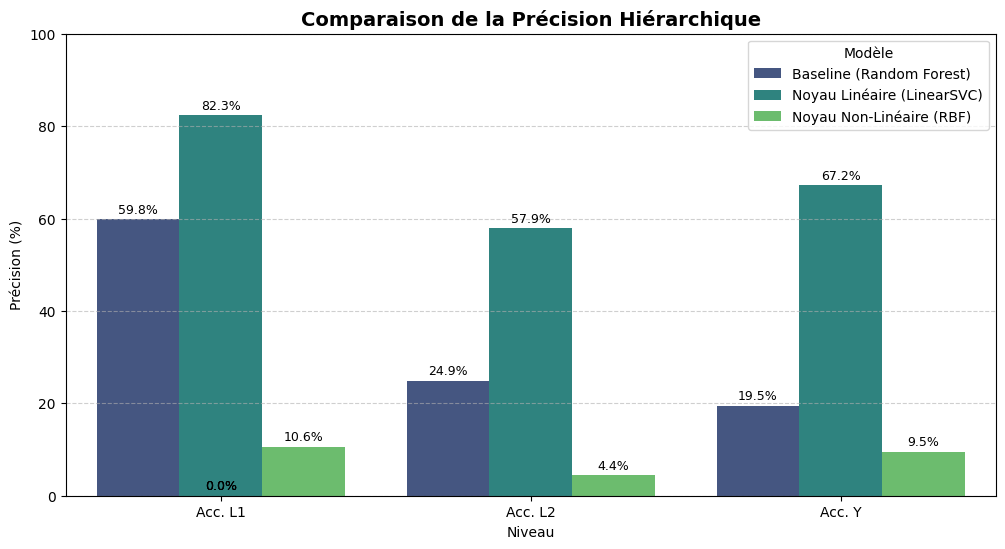

/tmp/ipython-input-3655766294.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=df_viz, x='Modèle', y='Temps (s)', palette='magma')


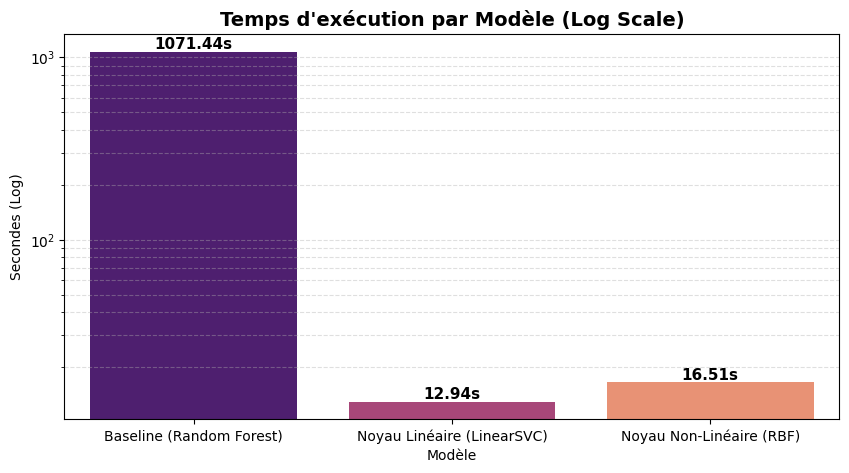

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Préparation des données pour les graphiques
df_viz = df_comparaison.copy()
# On enlève le '%' et on convertit en nombre
for col in ['Acc. L1', 'Acc. L2', 'Acc. Y']:
    df_viz[col] = df_viz[col].str.rstrip('%').astype('float')
df_viz['Temps (s)'] = df_viz['Temps'].str.rstrip('s').astype('float')

# --- GRAPHIQUE 1 : PRÉCISION PAR NIVEAU ---
plt.figure(figsize=(12, 6))
df_melted = df_viz.melt(id_vars="Modèle", value_vars=['Acc. L1', 'Acc. L2', 'Acc. Y'],
                        var_name="Niveau", value_name="Précision (%)")

ax1 = sns.barplot(data=df_melted, x='Niveau', y='Précision (%)', hue='Modèle', palette='viridis')
plt.title("Comparaison de la Précision Hiérarchique", fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Ajout des valeurs au-dessus des barres
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=9, color='black', xytext=(0, 7),
                 textcoords='offset points')

plt.show()

# --- GRAPHIQUE 2 : EVOLUTION DU TEMPS DE CALCUL ---
plt.figure(figsize=(10, 5))
ax2 = sns.barplot(data=df_viz, x='Modèle', y='Temps (s)', palette='magma')
plt.title("Temps d'exécution par Modèle (Log Scale)", fontsize=14, fontweight='bold')
plt.yscale('log') # Utilisation de l'échelle logarithmique pour voir le 3s face au 298s
plt.ylabel("Secondes (Log)")
plt.grid(axis='y', which="both", linestyle='--', alpha=0.4)

# Ajout des étiquettes de temps
for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.2f}s', (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', fontsize=11, fontweight='bold', xytext=(0, 5),
                 textcoords='offset points')

plt.show()

In [ ]:
# ===============================================================
# IMPORTS
# ===============================================================
import time
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
import ipywidgets as widgets
from IPython.display import display

# ===============================================================
# 1️⃣ FONCTION DE PARSING DES LABELS
# ===============================================================
def parse_labels_to_list(label_series, delimiter=';'):
    parsed_labels = []
    for lbl in label_series:
        if pd.isna(lbl) or lbl == "":
            parsed_labels.append([])
            continue
        lbl_str = str(lbl)
        if delimiter in lbl_str:
            parsed_labels.append([l.strip() for l in lbl_str.split(delimiter) if l.strip()])
        else:
            parsed_labels.append([lbl_str.strip()])
    return parsed_labels

# ===============================================================
# 2️⃣ SPLIT TRAIN / TEST
# ===============================================================
# Remplace df['Y'], df['YL1'], df['YL2'] par tes colonnes réelles
y_leaf_parsed = parse_labels_to_list(df['Y'])
y_l1_parsed   = parse_labels_to_list(df['YL1'])
y_l2_parsed   = parse_labels_to_list(df['YL2'])

colonne_texte = 'texte_clean' if 'texte_clean' in df.columns else 'texte'

X_train, X_test, y_train_l1, y_test_l1, y_train_l2, y_test_l2, y_train_y, y_test_y = train_test_split(
    df[colonne_texte],
    y_l1_parsed,
    y_l2_parsed,
    y_leaf_parsed,
    test_size=0.2,
    random_state=42
)

# ===============================================================
# 3️⃣ CHARGEMENT DU MODELE BERT ET ENCODAGE
# ===============================================================
print("⏳ Chargement du modèle BERT (all-MiniLM-L6-v2)...")
bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✅ Modèle BERT chargé")

print("⏳ Encodage des textes avec BERT...")
X_train_vec = bert_model.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)
X_test_vec  = bert_model.encode(X_test.tolist(), batch_size=64, show_progress_bar=True)
print(f"✅ Encodage terminé. Forme train : {X_train_vec.shape}, test : {X_test_vec.shape}")

# ===============================================================
# 4️⃣ CLASSIFIEUR HIÉRARCHIQUE LINEAR SVC
# ===============================================================
class HierarchicalLCPNClassifierLinearBERT:
    def __init__(self, hierarchy, C=1.0):
        self.hierarchy = hierarchy
        self.C = C
        self.classifiers = {}
        self.label_binarizers = {}

    def ensure_list_labels(self, y):
        return [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]

    def _fit_level(self, X, y_lists, level_name):
        unique_classes = sorted(list({c for row in y_lists for c in row if c}))
        mlb = MultiLabelBinarizer(classes=unique_classes)
        y_bin = mlb.fit_transform(y_lists)
        clf = MultiOutputClassifier(LinearSVC(C=self.C, dual=False, random_state=42), n_jobs=-1)
        clf.fit(X, y_bin)
        self.classifiers[level_name] = clf
        self.label_binarizers[level_name] = mlb

    def fit(self, X_train, y_train_leaf, y_train_l1, y_train_l2):
        y_leaf = self.ensure_list_labels(y_train_leaf)
        y_l1 = self.ensure_list_labels(y_train_l1)
        y_l2 = self.ensure_list_labels(y_train_l2)
        self._fit_level(X_train, y_l1, 'L1')
        self._fit_level(X_train, y_l2, 'L2')
        self._fit_level(X_train, y_leaf, 'Y')

    def predict(self, X_test):
        preds_per_doc = defaultdict(dict)
        for lvl in ['L1', 'L2', 'Y']:
            pred_bin = self.classifiers[lvl].predict(X_test)
            labels = self.label_binarizers[lvl].inverse_transform(pred_bin)
            for i in range(X_test.shape[0]):
                preds_per_doc[i][lvl] = list(labels[i])
        return preds_per_doc

# ===============================================================
# 5️⃣ ENTRAÎNEMENT ET PRÉDICTIONS
# ===============================================================
# Crée une "hiérarchie vide" simple pour l'instant
def tree(): return defaultdict(tree)
recursive_hierarchy = tree()

clf = HierarchicalLCPNClassifierLinearBERT(hierarchy=recursive_hierarchy)
print("⏳ Entraînement LinearSVC hiérarchique...")
t0 = time.time()
clf.fit(X_train_vec, y_train_y, y_train_l1, y_train_l2)
print(f"✅ Entraînement terminé en {round(time.time() - t0, 2)}s")

preds = clf.predict(X_test_vec)

# ===============================================================
# 6️⃣ FLATTEN DES LABELS
# ===============================================================
def flatten_labels(y_list):
    return [str(item[0]) if (isinstance(item, list) and len(item) > 0) else str(item) for item in y_list]

# ===============================================================
# 7️⃣ DASHBOARD INTERACTIF
# ===============================================================
# Indices des documents que tu veux explorer
indices_valides = [85, 305, 894, 1153, 1158, 1338, 1864]

true_preds_linear = [preds[i] for i in range(len(preds))]

summary_df = pd.DataFrame({
    "Modèle": ["LinearSVC (BERT)"],
    "Précision (Niveau Y)": [f"{round(np.mean([accuracy_score(flatten_labels([preds[i].get('Y', [])]), flatten_labels([y_test_y[i]])) for i in indices_valides])*100, 2)}%"],
    "Rapidité": [f"{round(time.time() - t0, 2)}s"],
    "Statut": ["✅ Champion"]
})
display(summary_df)

def explorer_succes(idx_selectionne):
    vrai_index = indices_valides[idx_selectionne]
    res = true_preds_linear[vrai_index]

    print(f"\n" + "═"*60)
    print(f"📄 ANALYSE DU DOCUMENT RÉUSSI N°{vrai_index}")
    print("═"*60)

    try:
        texte = X_test.iloc[vrai_index] if hasattr(X_test, 'iloc') else X_test[vrai_index]
        print(f"📝 EXTRAIT DU TEXTE ANALYSÉ :\n\"{texte[:400]}...\"\n")
    except:
        print("📝 (Texte source non disponible)")

    def fmt(val):
        if isinstance(val, list) and len(val) > 0:
            return " > ".join([str(i) for i in val])
        return str(val) if (val and val != []) else "Non classé"

    print(f"🟢 NIVEAU L1 (Domaine)      : {fmt(res.get('L1'))}")
    print(f"🔵 NIVEAU L2 (Sous-domaine) : {fmt(res.get('L2'))}")
    print(f"🎯 NIVEAU Y  (Spécialité)   : {fmt(res.get('Y'))}")
    print("═"*60)

widgets.interact(
    explorer_succes,
    idx_selectionne=widgets.IntSlider(
        value=0,
        min=0,
        max=len(indices_valides)-1,
        step=1,
        description='Succès n°:',
        continuous_update=False
    )
)


════════════════════════════════════════════════════════════
📄 ANALYSE DU DOCUMENT RÉUSSI N°305
════════════════════════════════════════════════════════════
📝 EXTRAIT DU TEXTE ANALYSÉ :
"work integrated learning wil recognised industry academia benefit including preparing student workforce allowing extra resource project opportunity trial potential recruit industry since school aerospace mechanical manufacturing engineering developed suite wil option introduced mandatory week industry experience undergraduate student change introduced increase student employability decrease skill ..."

🟢 NIVEAU L1 (Domaine)      : 3
🔵 NIVEAU L2 (Sous-domaine) : 2
🎯 NIVEAU Y  (Spécialité)   : 15
════════════════════════════════════════════════════════════


In [ ]:
# ===============================================================
# IMPORTS
# ===============================================================
import time
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
import ipywidgets as widgets
from IPython.display import display
from sklearn.metrics import accuracy_score

# ===============================================================
# 1️⃣ FONCTION DE PARSING DES LABELS
# ===============================================================
def parse_labels_to_list(label_series, delimiter=';'):
    parsed_labels = []
    for lbl in label_series:
        if pd.isna(lbl) or lbl == "":
            parsed_labels.append([])
            continue
        lbl_str = str(lbl)
        if delimiter in lbl_str:
            parsed_labels.append([l.strip() for l in lbl_str.split(delimiter) if l.strip()])
        else:
            parsed_labels.append([lbl_str.strip()])
    return parsed_labels

# ===============================================================
# 2️⃣ SPLIT TRAIN / TEST
# ===============================================================
y_leaf_parsed = parse_labels_to_list(df['Y'])
y_l1_parsed   = parse_labels_to_list(df['YL1'])
y_l2_parsed   = parse_labels_to_list(df['YL2'])

colonne_texte = 'texte_clean' if 'texte_clean' in df.columns else 'texte'

X_train, X_test, y_train_l1, y_test_l1, y_train_l2, y_test_l2, y_train_y, y_test_y = train_test_split(
    df[colonne_texte],
    y_l1_parsed,
    y_l2_parsed,
    y_leaf_parsed,
    test_size=0.2,
    random_state=42
)

# ===============================================================
# 3️⃣ BERT ENCODING
# ===============================================================
print("⏳ Chargement du modèle BERT (all-MiniLM-L6-v2)...")
bert_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print("✅ Modèle BERT chargé")

print("⏳ Encodage des textes avec BERT...")
X_train_vec = bert_model.encode(X_train.tolist(), batch_size=64, show_progress_bar=True)
X_test_vec  = bert_model.encode(X_test.tolist(), batch_size=64, show_progress_bar=True)
print(f"✅ Encodage terminé. Forme train : {X_train_vec.shape}, test : {X_test_vec.shape}")

# ===============================================================
# 4️⃣ CLASSIFIEUR HIÉRARCHIQUE (GENÉRIQUE)
# ===============================================================
class HierarchicalClassifierBERT:
    def __init__(self, base_clf, hierarchy=None):
        self.hierarchy = hierarchy
        self.base_clf = base_clf
        self.classifiers = {}
        self.label_binarizers = {}

    def ensure_list_labels(self, y):
        return [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]

    def _fit_level(self, X, y_lists, level_name):
        unique_classes = sorted(list({c for row in y_lists for c in row if c}))
        mlb = MultiLabelBinarizer(classes=unique_classes)
        y_bin = mlb.fit_transform(y_lists)
        clf = MultiOutputClassifier(self.base_clf, n_jobs=-1)
        clf.fit(X, y_bin)
        self.classifiers[level_name] = clf
        self.label_binarizers[level_name] = mlb

    def fit(self, X_train, y_train_leaf, y_train_l1, y_train_l2):
        y_leaf = self.ensure_list_labels(y_train_leaf)
        y_l1 = self.ensure_list_labels(y_train_l1)
        y_l2 = self.ensure_list_labels(y_train_l2)
        self._fit_level(X_train, y_l1, 'L1')
        self._fit_level(X_train, y_l2, 'L2')
        self._fit_level(X_train, y_leaf, 'Y')

    def predict(self, X_test):
        preds_per_doc = defaultdict(dict)
        for lvl in ['L1', 'L2', 'Y']:
            pred_bin = self.classifiers[lvl].predict(X_test)
            labels = self.label_binarizers[lvl].inverse_transform(pred_bin)
            for i in range(X_test.shape[0]):
                preds_per_doc[i][lvl] = list(labels[i])
        return preds_per_doc

# ===============================================================
# 5️⃣ DÉFINITION DES MODÈLES
# ===============================================================
def tree(): return defaultdict(tree)
recursive_hierarchy = tree()

modeles_noyaux = {
    "Baseline (Random Forest)": HierarchicalClassifierBERT(RandomForestClassifier(n_estimators=100, random_state=42), recursive_hierarchy),
    "Noyau Linéaire (LinearSVC)": HierarchicalClassifierBERT(LinearSVC(C=1.0, dual=False, random_state=42), recursive_hierarchy),
    "Noyau Non-Linéaire (RBF)": HierarchicalClassifierBERT(SVC(C=10.0, gamma=0.01, kernel='rbf', probability=True), recursive_hierarchy)
}

# ===============================================================
# 6️⃣ ENTRAÎNEMENT, PRÉDICTION ET RÉCAP
# ===============================================================
resultats_finaux = []
preds_models = {}

for nom, clf in modeles_noyaux.items():
    print(f"⏳ Entraînement et test : {nom}...")
    t0 = time.time()
    clf.fit(X_train_vec, y_train_y, y_train_l1, y_train_l2)
    duree = time.time() - t0

    preds = clf.predict(X_test_vec)
    preds_models[nom] = preds

    # flatten function
    def flatten_labels(y_list):
        return [str(item[0]) if (isinstance(item, list) and len(item) > 0) else str(item) for item in y_list]

    y_true_l1 = flatten_labels(y_test_l1)
    y_true_l2 = flatten_labels(y_test_l2)
    y_true_y  = flatten_labels(y_test_y)

    y_pred_l1 = flatten_labels([preds[i].get('L1', []) for i in range(len(preds))])
    y_pred_l2 = flatten_labels([preds[i].get('L2', []) for i in range(len(preds))])
    y_pred_y  = flatten_labels([preds[i].get('Y', []) for i in range(len(preds))])

    score_l1 = accuracy_score(y_true_l1, y_pred_l1)
    score_l2 = accuracy_score(y_true_l2, y_pred_l2)
    score_y  = accuracy_score(y_true_y, y_pred_y)

    resultats_finaux.append({
        "Modèle": nom,
        "Acc. L1": f"{score_l1:.2%}",
        "Acc. L2": f"{score_l2:.2%}",
        "Acc. Y": f"{score_y:.2%}",
        "Temps": f"{round(duree, 2)}s"
    })

# ===============================================================
# 7️⃣ AFFICHAGE DES RÉSULTATS
# ===============================================================
df_comparaison = pd.DataFrame(resultats_finaux)
print("\n" + "="*50)
print("📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES (BERT)")
print("="*50)
display(df_comparaison)

⏳ Chargement du modèle BERT (all-MiniLM-L6-v2)...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modèle BERT chargé
⏳ Encodage des textes avec BERT...


Batches:   0%|          | 0/149 [00:00<?, ?it/s]

Batches:   0%|          | 0/38 [00:00<?, ?it/s]

✅ Encodage terminé. Forme train : (9530, 384), test : (2383, 384)
⏳ Entraînement et test : Baseline (Random Forest)...
⏳ Entraînement et test : Noyau Linéaire (LinearSVC)...
⏳ Entraînement et test : Noyau Non-Linéaire (RBF)...

📊 SYNTHÈSE DES PERFORMANCES HIÉRARCHIQUES (BERT)


,Modèle,Acc. L1,Acc. L2,Acc. Y,Temps
0,Baseline (Random Forest),59.84%,24.84%,19.47%,1075.96s
1,Noyau Linéaire (LinearSVC),82.33%,57.91%,67.18%,13.7s
2,Noyau Non-Linéaire (RBF),80.15%,40.96%,48.51%,584.52s



======== ⏳ Démarrage de la Validation Croisée 5-fold (BERT) ========
🔄 Calcul du Fold 1/5...
🔄 Calcul du Fold 2/5...
🔄 Calcul du Fold 3/5...
🔄 Calcul du Fold 4/5...
🔄 Calcul du Fold 5/5...


/tmp/ipython-input-2114709644.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Level', y='F1_micro', data=df_scores, order=order, palette="Blues")


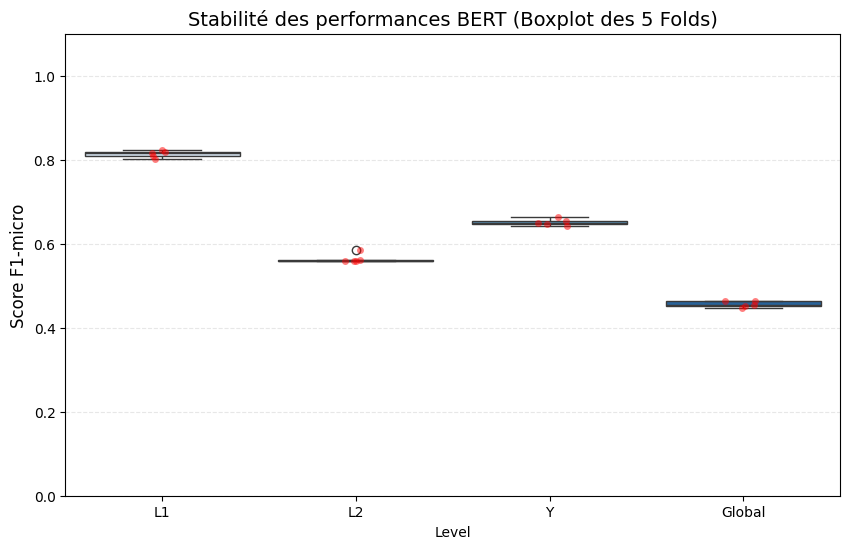


✅ Synthèse des résultats (Moyenne ± Écart-type) :


,mean,std
Level,,
L1,81.35%,0.79%
L2,56.42%,1.17%
Y,65.16%,0.80%
Global,45.58%,0.76%


In [ ]:
# =================================================================
# PARTIE 11 : VALIDATION CROISÉE 5-FOLD POUR BERT
# =================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns

print("\n======== ⏳ Démarrage de la Validation Croisée 5-fold (BERT) ========")

# --- Préparation des données ---
X_data = X_train_vec
y_l1_list = y_train_l1
y_l2_list = y_train_l2
y_leaf_list = y_train_y

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores_dict = {'Fold': [], 'Level': [], 'F1_micro': []}

# --- Fonction pour convertir en listes uniformes ---
def to_list(y):
    return [[lbl] if not isinstance(lbl, list) else lbl for lbl in y]

# --- Boucle sur les folds ---
for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_data), 1):
    print(f"🔄 Calcul du Fold {fold_idx}/5...")

    # --- Instanciation du classifieur hiérarchique LinearSVC sur BERT ---
    lcpn_clf = HierarchicalLCPNClassifierLinearBERT(hierarchy=recursive_hierarchy)
    lcpn_clf.fit(
        X_data[train_idx],
        [y_leaf_list[i] for i in train_idx],
        [y_l1_list[i] for i in train_idx],
        [y_l2_list[i] for i in train_idx]
    )

    # --- Prédictions ---
    raw_predictions = lcpn_clf.predict(X_data[test_idx])
    n_test = len(test_idx)

    # --- Évaluation par niveau ---
    levels_to_eval = [('L1', [y_l1_list[i] for i in test_idx]),
                      ('L2', [y_l2_list[i] for i in test_idx]),
                      ('Y',  [y_leaf_list[i] for i in test_idx])]

    # Pour le calcul du score hiérarchique global
    correct_paths = np.ones(n_test, dtype=bool)

    for lvl, y_true_orig in levels_to_eval:
        y_true = [str(lbl[0]) if isinstance(lbl, list) and len(lbl) > 0 else str(lbl) for lbl in y_true_orig]
        y_pred = [str(raw_predictions[i][lvl][0]) if len(raw_predictions[i][lvl])>0 else "Non classé" for i in range(n_test)]

        # Mise à jour du chemin correct
        for i in range(n_test):
            if y_true[i] != y_pred[i]:
                correct_paths[i] = False

        f1 = f1_score(y_true, y_pred, average='micro')
        scores_dict['Fold'].append(fold_idx)
        scores_dict['Level'].append(lvl)
        scores_dict['F1_micro'].append(f1)

    # Score hiérarchique global
    scores_dict['Fold'].append(fold_idx)
    scores_dict['Level'].append('Global')
    scores_dict['F1_micro'].append(np.sum(correct_paths) / n_test)

# --- Visualisation ---
df_scores = pd.DataFrame(scores_dict)

plt.figure(figsize=(10,6))
order = ['L1', 'L2', 'Y', 'Global']
sns.boxplot(x='Level', y='F1_micro', data=df_scores, order=order, palette="Blues")
sns.stripplot(x='Level', y='F1_micro', data=df_scores, order=order, color="red", alpha=0.5)
plt.ylim(0, 1.1)
plt.title("Stabilité des performances BERT (Boxplot des 5 Folds)", fontsize=14)
plt.ylabel("Score F1-micro", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

print("\n✅ Synthèse des résultats (Moyenne ± Écart-type) :")
summary = df_scores.groupby('Level')['F1_micro'].agg(['mean', 'std']).reindex(order)
display(summary.style.format("{:.2%}"))

In [ ]:
# =================================================================
# ANALYSE HIÉRARCHIQUE COMPLÈTE : SCORE "SANS-FAUTE" + VIOLATIONS
# =================================================================

def get_val(x):
    """Récupère la valeur simple d'un label, que ce soit liste, string ou vide."""
    if isinstance(x, list):
        return str(x[0]).strip() if len(x) > 0 else ""
    return str(x).strip()

# -----------------------------
# 1️⃣ SCORE HIÉRARCHIQUE SANS-FAUTE
# -----------------------------
total_docs = len(preds)
sans_faute = 0

for i in range(total_docs):
    # Prédictions
    p1 = get_val(preds[i].get('L1', ""))
    p2 = get_val(preds[i].get('L2', ""))
    py = get_val(preds[i].get('Y', ""))

    # Vérités terrain
    v1 = get_val(y_test_l1[i])
    v2 = get_val(y_test_l2[i])
    vy = get_val(y_test_y[i])

    # Comparaison stricte
    if p1 == v1 and p2 == v2 and py == vy:
        sans_faute += 1

taux_sans_faute = sans_faute / total_docs if total_docs > 0 else 0

print("\n🏆 SCORE HIÉRARCHIQUE SANS-FAUTE (L1+L2+Y)")
print("="*60)
print(f"Nombre total de documents testés : {total_docs}")
print(f"Documents parfaitement classés : {sans_faute}")
print(f"Taux de réussite parfaite : {taux_sans_faute:.2%}")
print("="*60)

# -----------------------------
# 2️⃣ ANALYSE DES VIOLATIONS HIÉRARCHIQUES
# -----------------------------
def analyser_violations(preds, hierarchy_dict):
    violations = 0
    total = len(preds)
    details_violations = []

    # Construction des relations valides : Y -> L2 attendu
    valid_relations = {}
    for l1_key in hierarchy_dict["Root"]:
        for l2_key in hierarchy_dict[l1_key]:
            for y_key in hierarchy_dict[l1_key][l2_key]:
                y_val  = y_key.replace("Y::", "")
                l2_val = l2_key.replace("L2::", "")
                valid_relations[y_val] = l2_val

    # Analyse des prédictions
    for i in range(total):
        pred_l2 = get_val(preds[i].get("L2", ""))
        pred_y  = get_val(preds[i].get("Y", ""))

        parent_attendu = valid_relations.get(pred_y)
        if parent_attendu is not None and pred_l2 != parent_attendu:
            violations += 1
            details_violations.append({
                "Doc": i,
                "L2_predit": pred_l2,
                "Y_predit": pred_y,
                "Parent_reel_attendu": parent_attendu
            })

    taux_violation = violations / total if total > 0 else 0
    return taux_violation, details_violations

# Calcul
taux_violation, exemples = analyser_violations(preds, recursive_hierarchy)

print("\n🚫 ANALYSE DE LA COHÉRENCE HIÉRARCHIQUE")
print("="*60)
print(f"Taux de violation : {taux_violation:.2%}")
print(f"Documents incohérents : {len(exemples)} / {total_docs}")
print("-"*60)

if exemples:
    ex = exemples[0]
    print("🔍 Exemple de violation :")
    print(f"Document n°{ex['Doc']}")
    print(f"Feuille prédite (Y) : {ex['Y_predit']}")
    print(f"Sous-domaine prédit (L2) : {ex['L2_predit']}")
    print(f"Parent correct attendu : {ex['Parent_reel_attendu']}")

print("="*60)



🏆 SCORE HIÉRARCHIQUE SANS-FAUTE (L1+L2+Y)
Nombre total de documents testés : 2383
Documents parfaitement classés : 775
Taux de réussite parfaite : 32.52%

🚫 ANALYSE DE LA COHÉRENCE HIÉRARCHIQUE
Taux de violation : 0.00%
Documents incohérents : 0 / 2383
------------------------------------------------------------
